# Cluster 3

In [91]:
import pandas as pd
import numpy as np
import random
import os

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

In [92]:
df = pd.read_csv('../../Clusters/cluster_3.csv')

In [93]:
df.head()

,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Cluster
0,4,0,0.510359,0.537287,0.552546,0.600023,0.600023,0.999009,0.797406,0.809313,...,0.001124,0.623993,0.600019,0.840313,0.279878,0.026880,0.565549,1,0.028858,3
1,5,0,0.546044,0.617804,0.600567,0.597717,0.597717,0.998992,0.797580,0.809485,...,0.003546,0.624559,0.597713,0.843723,0.281660,0.026861,0.565473,1,0.024103,3
2,12,0,0.541705,0.608046,0.590128,0.599173,0.599173,0.999012,0.797512,0.809413,...,0.002070,0.623986,0.599171,0.842948,0.279409,0.026872,0.565515,1,0.030706,3
3,19,0,0.548920,0.586840,0.588040,0.610206,0.610206,0.999008,0.797433,0.809343,...,0.003342,0.623728,0.610204,0.843384,0.283137,0.026791,0.565159,1,0.021680,3
4,21,0,0.534490,0.596217,0.588522,0.604722,0.604722,0.999116,0.797546,0.809464,...,0.020846,0.617242,0.604721,0.843293,0.285631,0.026930,0.565744,1,0.019073,3


In [94]:
print(df.shape)
df.describe()

(1024, 98)


,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Cluster
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,...,1.024000e+03,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.0,1024.000000,1024.0
mean,2917.467773,0.005859,0.519735,0.579616,0.566908,0.602804,0.602775,0.999031,0.797473,0.809380,...,2.747070e+07,0.623846,0.602802,0.842223,0.282536,0.027036,0.565770,1.0,0.026758,3.0
std,1653.778441,0.076359,0.040891,0.037394,0.038224,0.006308,0.006275,0.000065,0.000097,0.000078,...,4.624546e+08,0.001510,0.006308,0.001761,0.005014,0.001267,0.005617,0.0,0.008944,0.0
min,4.000000,0.000000,0.411739,0.471271,0.457359,0.592557,0.592535,0.998914,0.797312,0.809246,...,1.135300e-04,0.607489,0.592554,0.830736,0.276253,0.022916,0.522361,1.0,0.012028,3.0
25%,1494.750000,0.000000,0.493723,0.556899,0.542119,0.598558,0.598531,0.998988,0.797417,0.809334,...,1.182458e-03,0.623719,0.598554,0.841265,0.279316,0.026801,0.565209,1.0,0.020223,3.0
50%,2938.500000,0.000000,0.512480,0.573812,0.560549,0.601374,0.601349,0.999016,0.797454,0.809362,...,2.584620e-03,0.623866,0.601374,0.842139,0.281144,0.026840,0.565386,1.0,0.025211,3.0
75%,4293.750000,0.000000,0.539170,0.595794,0.585537,0.605199,0.605181,0.999054,0.797505,0.809405,...,5.964594e-03,0.624097,0.605195,0.843031,0.284370,0.026940,0.565795,1.0,0.031120,3.0
max,5804.000000,1.000000,0.755131,0.779546,0.757910,0.650319,0.650319,0.999343,0.799074,0.810556,...,9.650000e+09,0.645372,0.650317,0.853640,0.328568,0.051601,0.735958,1.0,0.071833,3.0


Notice than some features are normalized between 0 and 1. Some features such as "Total assets to GNP price" are not normalized with some samples having larges values. All features seem to be numerical

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 98 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Index                                                    1024 non-null   int64  
 1   Bankrupt?                                                1024 non-null   int64  
 2   ROA(C) before interest and depreciation before interest  1024 non-null   float64
 3   ROA(A) before interest and % after tax                   1024 non-null   float64
 4   ROA(B) before interest and depreciation after tax        1024 non-null   float64
 5   Operating Gross Margin                                   1024 non-null   float64
 6   Realized Sales Gross Margin                              1024 non-null   float64
 7   Operating Profit Rate                                    1024 non-null   float64
 8   Pre-tax net Interest Rate              

In [96]:
# Find number and percentage of companies with Bankrupt? = 1
bankrupt_count = (df["Bankrupt?"] == 1).sum()
total_count = len(df)
bankrupt_percentage = (bankrupt_count / total_count) * 100

print("Bankruptcy Distribution:")
print("="*60)
print(f"Companies with Bankrupt? = 1: {bankrupt_count}")
print(f"Companies with Bankrupt? = 0: {total_count - bankrupt_count}")
print(f"Total companies: {total_count}")
print(f"\nBankruptcy Rate: {bankrupt_percentage:.2f}%")
print(f"Non-bankruptcy Rate: {100 - bankrupt_percentage:.2f}%")

Bankruptcy Distribution:
Companies with Bankrupt? = 1: 6
Companies with Bankrupt? = 0: 1018
Total companies: 1024

Bankruptcy Rate: 0.59%
Non-bankruptcy Rate: 99.41%


## Boolean features

In [97]:
df["Net Income Flag"].describe()

count    1024.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Net Income Flag, dtype: float64

In [98]:
# Check unique values for Net Income Flag
print("Unique values in Net Income Flag:")
print(df["Net Income Flag"].unique())
print(f"\nValue counts for Net Income Flag:")
print(df["Net Income Flag"].value_counts())
print(f"\nTotal samples: {len(df)}")
print(f"Samples with Net Income Flag = 1: {(df['Net Income Flag'] == 1).sum()}")
print(f"All values are 1: {(df['Net Income Flag'] == 1).all()}")

Unique values in Net Income Flag:
[1]

Value counts for Net Income Flag:
Net Income Flag
1    1024
Name: count, dtype: int64

Total samples: 1024
Samples with Net Income Flag = 1: 1024
All values are 1: True


In [99]:
df["Liability-Assets Flag"].describe()

count    1024.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Liability-Assets Flag, dtype: float64

In [100]:
# Check unique values for Net Income Flag
print("Unique values in Liability-Assets Flag:")
print(df["Liability-Assets Flag"].unique())
print(f"\nValue counts for Liability-Assets Flag:")
print(df["Liability-Assets Flag"].value_counts())
print(f"\nTotal samples: {len(df)}")
print(f"Samples with Liability-Assets Flag = 1: {(df['Liability-Assets Flag'] == 1).sum()}")
print(f"All values are 0: {(df['Liability-Assets Flag'] == 0).all()}")

Unique values in Liability-Assets Flag:
[0]

Value counts for Liability-Assets Flag:
Liability-Assets Flag
0    1024
Name: count, dtype: int64

Total samples: 1024
Samples with Liability-Assets Flag = 1: 0
All values are 0: True


We have two categorical (boolean) features Net Income Flag and Liability-Assets Flag. Both features are heavily skewed.

## Identify Constant features

In [101]:
# Identify constant features (features with only one unique value)
constant_features = []
for col in df.columns:
    if df[col].nunique() == 1:
        constant_features.append(col)

print(f"Constant features found: {len(constant_features)}\n")
if constant_features:
    for feature in constant_features:
        unique_val = df[feature].unique()[0]
        print(f"  - {feature}: {unique_val}")
else:
    print("No constant features found.")

Constant features found: 3

  - Liability-Assets Flag: 0
  - Net Income Flag: 1
  - Cluster: 3


## Drop constant features and index

In [102]:
df = df.drop(columns=["Index", "Liability-Assets Flag", "Net Income Flag", "Cluster"])
df.shape

(1024, 94)

In [103]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Current Liability to Current Assets,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,0,0.510359,0.537287,0.552546,0.600023,0.600023,0.999009,0.797406,0.809313,0.303468,...,0.031509,0.799277,0.001124,0.623993,0.600019,0.840313,0.279878,0.026880,0.565549,0.028858
1,0,0.546044,0.617804,0.600567,0.597717,0.597717,0.998992,0.797580,0.809485,0.303810,...,0.031999,0.834985,0.003546,0.624559,0.597713,0.843723,0.281660,0.026861,0.565473,0.024103
2,0,0.541705,0.608046,0.590128,0.599173,0.599173,0.999012,0.797512,0.809413,0.303647,...,0.035987,0.832890,0.002070,0.623986,0.599171,0.842948,0.279409,0.026872,0.565515,0.030706
3,0,0.548920,0.586840,0.588040,0.610206,0.610206,0.999008,0.797433,0.809343,0.303520,...,0.031397,0.827921,0.003342,0.623728,0.610204,0.843384,0.283137,0.026791,0.565159,0.021680
4,0,0.534490,0.596217,0.588522,0.604722,0.604722,0.999116,0.797546,0.809464,0.303490,...,0.023915,0.822637,0.020846,0.617242,0.604721,0.843293,0.285631,0.026930,0.565744,0.019073


## Missing Values Analysis

In [104]:
# Check for missing values
print("Missing values summary:")
print("="*50)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create summary dataframe
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_values.values,
    'Missing %': missing_percent.values
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_summary) == 0:
    print("\n✓ No missing values found in the dataset!")
else:
    print(f"\nFound {len(missing_summary)} columns with missing values:\n")
    print(missing_summary.to_string(index=False))

print(f"\n{'='*50}")
print(f"Total samples: {len(df)}")
print(f"Total features: {len(df.columns)}")

Missing values summary:

✓ No missing values found in the dataset!

Total samples: 1024
Total features: 94


## Feature Normalization Analysis

In [105]:
# Identify features NOT normalized between 0 and 1
non_normalized = []
normalization_summary = []

for col in df.columns:
    if col == "Bankrupt?":  # Skip target variable
        continue
    
    min_val = df[col].min()
    max_val = df[col].max()
    is_normalized = (min_val >= 0) and (max_val <= 1)
    
    normalization_summary.append({
        'Feature': col,
        'Min': min_val,
        'Max': max_val,
        'Normalized': 'Yes' if is_normalized else 'No'
    })
    
    if not is_normalized:
        non_normalized.append(col)

# Create summary dataframe
norm_df = pd.DataFrame(normalization_summary)
non_norm_df = norm_df[norm_df['Normalized'] == 'No'].sort_values('Min')

print(f"Features NOT normalized between 0 and 1: {len(non_normalized)}\n")
print(non_norm_df.to_string(index=False))
print(f"\n{'='*80}")
print(f"Features normalized between 0 and 1: {len(norm_df) - len(non_normalized)}")
print(f"Total features: {len(norm_df)}")

Features NOT normalized between 0 and 1: 14

                              Feature      Min          Max Normalized
Research and development expense rate 0.000000 9.980000e+09         No
  Interest-bearing debt interest rate 0.000000 9.900000e+08         No
           Allocation rate per person 0.000000 9.570000e+09         No
               Cash/Current Liability 0.000000 9.410000e+09         No
Long-term Liability to Current Assets 0.000000 9.540000e+09         No
                   Cash Turnover Rate 0.000000 1.000000e+10         No
          Inventory/Current Liability 0.000000 9.910000e+09         No
            Quick Asset Turnover Rate 0.000100 9.990000e+09         No
          Current Asset Turnover Rate 0.000100 1.000000e+10         No
              Total Asset Growth Rate 0.000100 9.990000e+09         No
               Operating Expense Rate 0.000100 9.990000e+09         No
      Inventory Turnover Rate (times) 0.000100 9.950000e+09         No
                          Quick 

In [106]:
attributes_df = df.drop(columns=["Bankrupt?"])
target_df = df["Bankrupt?"]

print(attributes_df.shape)
print(target_df.shape)

(1024, 93)
(1024,)


In [107]:
from sklearn.preprocessing import MinMaxScaler

# Rebuild non_normalized list for attributes_df (with cleaned column names)
non_normalized_in_attrs = []
for col in attributes_df.columns:
    min_val = attributes_df[col].min()
    max_val = attributes_df[col].max()
    is_normalized = (min_val >= 0) and (max_val <= 1)
    
    if not is_normalized:
        non_normalized_in_attrs.append(col)

print(f"Features to scale: {len(non_normalized_in_attrs)}")

attributes_df_raw = attributes_df.copy()

# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply scaling to non-normalized features in attributes_df
if len(non_normalized_in_attrs) > 0:
    attributes_df[non_normalized_in_attrs] = scaler.fit_transform(attributes_df[non_normalized_in_attrs])
    print(f"Scaled {len(non_normalized_in_attrs)} features using MinMaxScaler")
else:
    print("No features to scale")

print(f"\nAttributes dataframe shape: {attributes_df.shape}")

Features to scale: 14
Scaled 14 features using MinMaxScaler

Attributes dataframe shape: (1024, 93)


In [108]:
# Verify all features in attributes_df are now normalized between 0 and 1
non_normalized = []
normalization_summary = []

tolerance = 1e-10

for col in attributes_df.columns:    
    min_val = attributes_df[col].min()
    max_val = attributes_df[col].max()
    is_normalized = (min_val >= -tolerance) and (max_val <= 1 + tolerance)
    
    normalization_summary.append({
        'Feature': col,
        'Min': min_val,
        'Max': max_val,
        'Normalized': 'Yes' if is_normalized else 'No'
    })
    
    if not is_normalized:
        non_normalized.append(col)

# Create summary dataframe
norm_df = pd.DataFrame(normalization_summary)
non_norm_df = norm_df[norm_df['Normalized'] == 'No'].sort_values('Min')

print(f"Features NOT normalized between 0 and 1: {len(non_normalized)}\n")
if len(non_normalized) > 0:
    print(non_norm_df.to_string(index=False))
else:
    print("✓ All features are now normalized!")
print(f"\n{'='*80}")
print(f"Features normalized between 0 and 1: {len(norm_df) - len(non_normalized)}")
print(f"Total features: {len(norm_df)}")

Features NOT normalized between 0 and 1: 0

✓ All features are now normalized!

Features normalized between 0 and 1: 93
Total features: 93


## Feature Variance Analysis

In [109]:

# Varriance filter was considered and tested but eventually discarded
'''
from sklearn.feature_selection import VarianceThreshold

# Keep features with variance above threshold
# Low variance = feature is nearly constant across all samples (not informative)
# High variance = feature changes significantly (more informative)
#selector = VarianceThreshold(threshold=0.000000)   # yields all 93 features, no filter
#selector = VarianceThreshold(threshold=0.0001)   # yields 52 features
selector = VarianceThreshold(threshold=0.001)   # yields 41 features
#selector = VarianceThreshold(threshold=0.01)    # yields 14 features
#selector = VarianceThreshold(threshold=0.1)    # yields 4 features
#selector = VarianceThreshold(threshold=0.12)    # yields ? features


selector.fit(attributes_df)
attributes_df_var = attributes_df.loc[:, selector.get_support()]

# Show dropped features
support_mask = selector.get_support()
dropped_features = attributes_df.columns[~support_mask].tolist()

print(f"Features remaining: {attributes_df_var.shape[1]}")
print(f"Features dropped: {len(dropped_features)}\n")
print("Dropped features (low variance):")
print("="*60)
for i, feature in enumerate(dropped_features, 1):
    variance = attributes_df[feature].var()
    print(f"{i}. {feature} (variance: {variance:.6f})")

'''


'\nfrom sklearn.feature_selection import VarianceThreshold\n\n# Keep features with variance above threshold\n# Low variance = feature is nearly constant across all samples (not informative)\n# High variance = feature changes significantly (more informative)\n#selector = VarianceThreshold(threshold=0.000000)   # yields all 93 features, no filter\n#selector = VarianceThreshold(threshold=0.0001)   # yields 52 features\nselector = VarianceThreshold(threshold=0.001)   # yields 41 features\n#selector = VarianceThreshold(threshold=0.01)    # yields 14 features\n#selector = VarianceThreshold(threshold=0.1)    # yields 4 features\n#selector = VarianceThreshold(threshold=0.12)    # yields ? features\n\n\nselector.fit(attributes_df)\nattributes_df_var = attributes_df.loc[:, selector.get_support()]\n\n# Show dropped features\nsupport_mask = selector.get_support()\ndropped_features = attributes_df.columns[~support_mask].tolist()\n\nprint(f"Features remaining: {attributes_df_var.shape[1]}")\nprint(f

In [110]:
# Variance filter not used
#print(attributes_df_var.shape)
#attributes_df_var.head()

## PCA dimentionality reduction

In [111]:

from sklearn.decomposition import PCA

n_components = 15

# Apply sklearn PCA
sklearn_pca = PCA(n_components=n_components, random_state=42)
#X_pca_sklearn = sklearn_pca.fit_transform(attributes_df_var)
X_pca_sklearn = sklearn_pca.fit_transform(attributes_df)

print(f"\nScikit-learn PCA Results:")
print(f"  Transformed data shape: {X_pca_sklearn.shape}")




Scikit-learn PCA Results:
  Transformed data shape: (1024, 15)


In [112]:
attributes_final = X_pca_sklearn

## Number of features used to train the model

In [113]:
attributes_final.shape

(1024, 15)

We are using **8 features** to train the model

## Stacking model

In [114]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

X = attributes_final
y = target_df


print(f"Class distribution - Negative: {(y == 0).sum()}, Positive: {(y == 1).sum()}")

# Base learners optimized for imbalanced data (sklearn only)
base_learners = [
    ('gb', GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        class_weight='balanced',
        probability=True,
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )),
    ('lr', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
]

# Meta-learner: Logistic Regression with balanced class weights
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

clf_cv = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=6
)
result_cv = clf_cv.fit(X, y).score(X, y)
#print(f"Stacking Model (with CV) - Training Accuracy: {round(result_cv, 3)}")

Class distribution - Negative: 1018, Positive: 6


MINORITY CLASS (Bankrupt? = 1) RECALL EVALUATION

Model WITH Cross-Validation:
  Recall (sklearn): 1.0000
  Recall Formula TP/(FN+TP): 1.0000
  Confusion Matrix: TP=6, FN=0, FP=27, TN=991


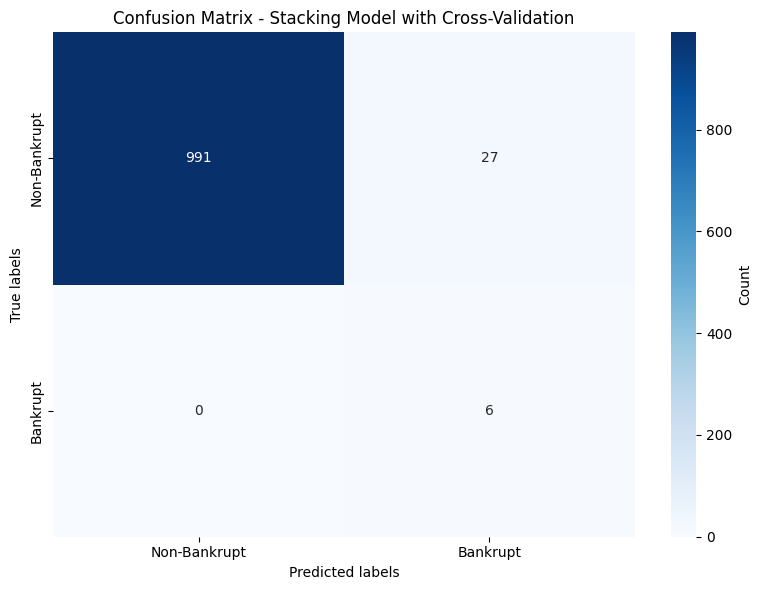


Detailed Classification Report (CV Model):
              precision    recall  f1-score   support

Non-Bankrupt       1.00      0.97      0.99      1018
    Bankrupt       0.18      1.00      0.31         6

    accuracy                           0.97      1024
   macro avg       0.59      0.99      0.65      1024
weighted avg       1.00      0.97      0.98      1024



In [115]:
from sklearn.metrics import recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_cv = clf_cv.predict(X)

print("="*80)
print("MINORITY CLASS (Bankrupt? = 1) RECALL EVALUATION")
print("="*80)

# Recall with cross-validation
recall_cv = recall_score(y, y_pred_cv, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()
recall_formula_cv = tp / (fn + tp)

print(f"\nModel WITH Cross-Validation:")
print(f"  Recall (sklearn): {recall_cv:.4f}")
print(f"  Recall Formula TP/(FN+TP): {recall_formula_cv:.4f}")
print(f"  Confusion Matrix: TP={tp}, FN={fn}, FP={fp}, TN={tn}")

# Create confusion matrix for cross-validation
cm_cv = confusion_matrix(y, y_pred_cv)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='g', ax=ax, cmap='Blues', cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix - Stacking Model with Cross-Validation')
ax.xaxis.set_ticklabels(['Non-Bankrupt', 'Bankrupt'])
ax.yaxis.set_ticklabels(['Non-Bankrupt', 'Bankrupt'])

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("Detailed Classification Report (CV Model):")
print(f"{'='*80}")
print(classification_report(y, y_pred_cv, target_names=['Non-Bankrupt', 'Bankrupt']))

## Summary of dimensionality experiments

| Dimentions | Method used for reduction | Recall of minority class |
|--|--|--|
| 93 |  None | 0.17 | 
| 52 | Variance filter | 1 |
| 41 | Variance filter | 1 |
| 14 | Variance filter | 0 |
| 4 | Variance filter | 0 |
| 24 | Variance -> 41 & PCA -> 24 | 1 |
| 12 | Variance -> 41 & PCA -> 12 | 1 |
| 9 | Variance -> 41 & PCA -> 9 | 1 |
| 8 | Variance -> 41 & PCA -> 8 | 1 |
| 15 | PCA | 1 |
| 8 | PCA | 1 |
| 7 | PCA | 0.3 |
| 7 | Variance -> 41 & PCA -> 7 | 0 |
| 6 | Variance -> 41 & PCA -> 6 | 0 |

We obtained a recall of the minority class of **1 (100%)** using **15** features as the input of the stacking model

# Final results

| Subgroup ID | Name | Companies | Bankrupt | TT | TF | N_features |
|---|---|---|---|---|---|---|
| 3 | Jefrey | 1024 | 6 | 6 | 0 | 15 |

## Export Preprocessing Pipeline and Stacking Model

Save the preprocessing pipeline and the fitted stacking model so they can be loaded and used from any other notebook to make predictions.

In [116]:
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# Define ColumnDropper transformer
class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drops specified columns from the dataframe."""
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=[c for c in self.columns_to_drop if c in X.columns])
        return X


# Define PreprocessorWrapper to fix the pipeline structure issue
class PreprocessorWrapper(BaseEstimator, TransformerMixin):
    """
    Wrapper that correctly applies the preprocessing pipeline.
    
    The original pipeline has a structural issue: the scaler was fitted on only 14 
    non-normalized columns, but the pipeline tries to feed it all 93 columns.
    
    This wrapper handles the proper column ordering and selective scaling.
    """
    def __init__(self, column_dropper, scaler, pca):
        self.column_dropper = column_dropper
        self.scaler = scaler
        self.pca = pca
        self.scaler_columns = list(scaler.feature_names_in_)
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Step 1: Drop columns
        X_dropped = self.column_dropper.transform(X)
        
        # Step 2: Apply scaler only to the columns it was fitted on (preserves column order)
        X_scaled = X_dropped.copy()
        X_scaled[self.scaler_columns] = self.scaler.transform(X_dropped[self.scaler_columns])
        
        # Step 3: Apply PCA
        return self.pca.transform(X_scaled)

In [117]:
# Create the fixed preprocessing pipeline using the wrapper
columns_to_drop = ["Index", "Liability-Assets Flag", "Net Income Flag", "Cluster"]

column_dropper = ColumnDropper(columns_to_drop=columns_to_drop)
preprocessor_wrapper = PreprocessorWrapper(
    column_dropper=column_dropper,
    scaler=scaler,
    pca=sklearn_pca
)

print(f"Preprocessor wrapper created:")
print(f"  Input: Raw cluster data with {len(df.columns)} columns")
print(f"  Output: {n_components} PCA components")
print(f"  Fixes: Properly handles selective column scaling while preserving order")

Preprocessor wrapper created:
  Input: Raw cluster data with 94 columns
  Output: 15 PCA components
  Fixes: Properly handles selective column scaling while preserving order


In [118]:
# Create a combined Predictor that includes both preprocessing and prediction
class Predictor(BaseEstimator):
    """
    Combined predictor that handles preprocessing and model prediction in one call.
    
    Usage:
        predictor = joblib.load('cluster_3_predictor.joblib')
        predictions = predictor.predict(new_data)
        probabilities = predictor.predict_proba(new_data)
    """
    def __init__(self, preprocessor, model):
        self.preprocessor = preprocessor
        self.model = model
    
    def predict(self, X):
        """Preprocess data and make predictions."""
        X_preprocessed = self.preprocessor.transform(X)
        return self.model.predict(X_preprocessed)
    
    def predict_proba(self, X):
        """Preprocess data and return probability estimates."""
        X_preprocessed = self.preprocessor.transform(X)
        return self.model.predict_proba(X_preprocessed)
    
    def __repr__(self):
        return f"Predictor(preprocessor={type(self.preprocessor).__name__}, model={type(self.model).__name__})"


# Create the combined predictor
predictor = Predictor(
    preprocessor=preprocessor_wrapper,
    model=clf_cv
)

print(f"Combined predictor created:")
print(f"  Preprocessor: {type(preprocessor_wrapper).__name__}")
print(f"  Model: {type(clf_cv).__name__}")
print(f"  Ready for single-file deployment")

# Save only the combined predictor
joblib.dump(predictor, 'cluster_3_predictor.joblib')
print("\n✓ Saved: cluster_3_predictor.joblib")

# Verify it can be loaded and used
loaded_predictor = joblib.load('cluster_3_predictor.joblib')
print(f"✓ Reload test passed: {loaded_predictor}")

# Test with a sample
test_predictions = loaded_predictor.predict(df.drop(columns=['Bankrupt?']).head(5))
test_probas = loaded_predictor.predict_proba(df.drop(columns=['Bankrupt?']).head(5))
print(f"✓ Functionality test passed")
print(f"  Sample predictions: {test_predictions}")
print(f"  Sample probabilities shape: {test_probas.shape}")

Combined predictor created:
  Preprocessor: PreprocessorWrapper
  Model: StackingClassifier
  Ready for single-file deployment

✓ Saved: cluster_3_predictor.joblib
✓ Reload test passed: Predictor(preprocessor=PreprocessorWrapper, model=StackingClassifier)
✓ Functionality test passed
  Sample predictions: [0 0 0 0 0]
  Sample probabilities shape: (5, 2)


In [119]:
# (Old approach - no longer needed, using single predictor file instead)
# joblib.dump(preprocessing_pipeline, 'cluster_3_preprocessing_pipeline.joblib')
# joblib.dump(clf_cv, 'cluster_3_stacking_model.joblib')
print("Note: Using single 'cluster_3_predictor.joblib' file for both preprocessing and prediction")
print("      No separate pipeline and model files needed.")

Note: Using single 'cluster_3_predictor.joblib' file for both preprocessing and prediction
      No separate pipeline and model files needed.


In [120]:
# Example: How to use the saved predictor from any other notebook
print("\n" + "="*70)
print("USAGE EXAMPLE: Making predictions on new data")
print("="*70)
print("""
# Load the combined predictor (preprocessing + model in one file)
import joblib
import pandas as pd

predictor = joblib.load('cluster_3_predictor.joblib')

# Load your new company data as a DataFrame
# (must have the same features as the original cluster_3.csv)
new_data = pd.read_csv('new_companies.csv')

# Make predictions (preprocessing is handled automatically)
predictions = predictor.predict(new_data)
probabilities = predictor.predict_proba(new_data)

# Display results
print("Predictions (0=Not Bankrupt, 1=Bankrupt):", predictions)
print("Probabilities:", probabilities)

# That's it! No need to handle preprocessing separately.
""")



USAGE EXAMPLE: Making predictions on new data

# Load the combined predictor (preprocessing + model in one file)
import joblib
import pandas as pd

predictor = joblib.load('cluster_3_predictor.joblib')

# Load your new company data as a DataFrame
# (must have the same features as the original cluster_3.csv)
new_data = pd.read_csv('new_companies.csv')

# Make predictions (preprocessing is handled automatically)
predictions = predictor.predict(new_data)
probabilities = predictor.predict_proba(new_data)

# Display results
print("Predictions (0=Not Bankrupt, 1=Bankrupt):", predictions)
print("Probabilities:", probabilities)

# That's it! No need to handle preprocessing separately.

